# Notebook 10 — Lag-revision experiment (Phase D)

Three publication-lag configurations side-by-side, generated by `scripts/lag_revision_experiment.py`:

| Config | pub_lag_y | pub_lag_x | Interpretation |
|---|---|---|---|
| `v1_legacy` | 1 | 1 | What v1 shipped — symmetric 1-week buffer between training cutoff and forecast date. |
| `backtest_clean` | 0 | 0 | Honest backtest — we already have finalized historical Trends data, no artificial delay. |
| `forecast_realistic` | 0 | 1 | Production-realistic — ETF close is same-day, Trends has ~1-week stabilization window. |

The hypothesis (per IMPLEMENTATION_PLAN_v2.md §5 D.5): `backtest_clean` improves RMSE marginally; the methodological clarity is the bigger value.


In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

p = Path.cwd().resolve()
while not (p / 'src' / 'gtrends_bayes').exists():
    if p == p.parent: raise RuntimeError('cannot find src/')
    p = p.parent
sys.path.insert(0, str(p / 'src'))
os.chdir(p)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/processed/backtest/lag_revision.csv')
print(f'rows: {len(df)} (expect 2 targets × 3 configs × 4 models = 24)')
df.head()

rows: 24 (expect 2 targets × 3 configs × 4 models = 24)


,target,config,model,n_obs,RMSE,RMSE/AR(4),hit_rate,ic_spearman,cov_50,cov_80,cov_95
0,HY,v1_legacy,BSTS (Trends),226,2.0790,1.2567,0.5244,0.0363,0.3673,0.6150,0.8274
1,HY,v1_legacy,AR(4),226,1.6543,1.0000,0.0400,-0.0686,0.2788,0.5708,0.7832
2,HY,v1_legacy,Naive RW,226,1.6336,0.9875,0.0400,-0.0685,0.3451,0.6106,0.7965
3,HY,v1_legacy,AR(4) + VIX,226,1.6412,0.9921,0.4667,-0.0822,0.3142,0.5487,0.7434
4,HY,backtest_clean,BSTS (Trends),227,1.9463,1.2712,0.4823,-0.0818,0.4097,0.6388,0.8370


## 1. RMSE by config (does backtest_clean improve over v1_legacy?)

In [2]:
rmse_pivot = df.pivot_table(index=['target', 'model'], columns='config', values='RMSE')
rmse_pivot = rmse_pivot[['v1_legacy', 'backtest_clean', 'forecast_realistic']]
rmse_pivot['Δ % (clean vs v1)'] = ((rmse_pivot['backtest_clean'] - rmse_pivot['v1_legacy']) / rmse_pivot['v1_legacy'] * 100).round(2)
rmse_pivot.round(4)

config                v1_legacy  backtest_clean  forecast_realistic  \
target model                                                          
HY     AR(4)             1.6543          1.5311              1.6543   
       AR(4) + VIX       1.6412          1.5077              1.6412   
       BSTS (Trends)     2.0790          1.9463              2.0788   
       Naive RW          1.6336          1.5104              1.6336   
IG     AR(4)             3.1774          2.9291              3.1774   
       AR(4) + VIX       3.1722          2.9209              3.1722   
       BSTS (Trends)     3.7583          3.5280              3.7649   
       Naive RW          3.1684          2.9172              3.1684   

config                Δ % (clean vs v1)  
target model                             
HY     AR(4)                      -7.45  
       AR(4) + VIX                -8.13  
       BSTS (Trends)              -6.38  
       Naive RW                   -7.54  
IG     AR(4)                      -7.81  
       AR(4) + VIX                -7.92  
       BSTS (Trends)              -6.13  
       Naive RW                   -7.93

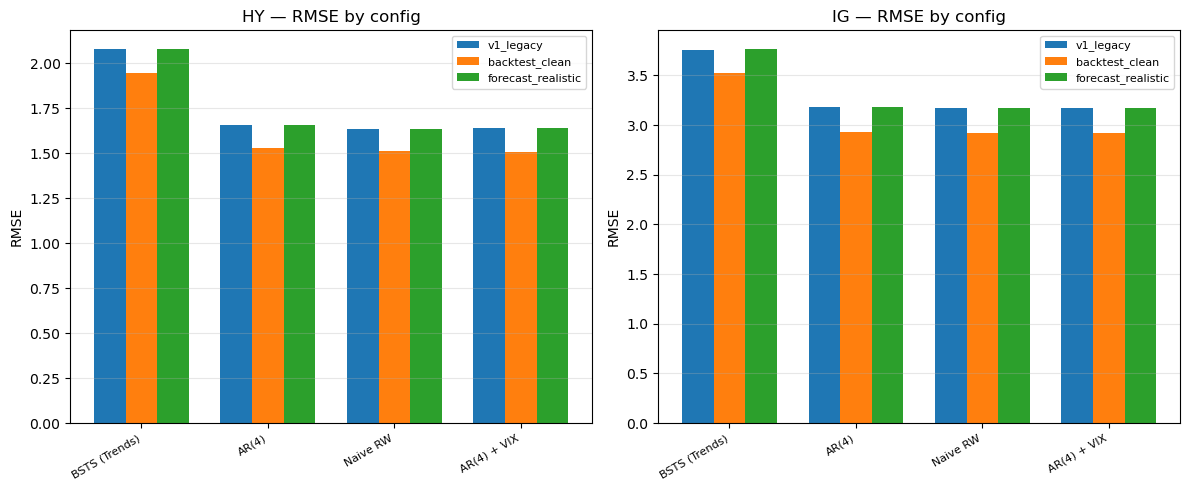

In [3]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, target in zip(axes, ['HY', 'IG']):
    sub = df[df.target == target]
    models = sub.model.unique()
    configs = ['v1_legacy', 'backtest_clean', 'forecast_realistic']
    x = np.arange(len(models))
    width = 0.25
    for i, cfg in enumerate(configs):
        vals = [sub[(sub.model == m) & (sub.config == cfg)]['RMSE'].iloc[0] for m in models]
        ax.bar(x + (i - 1) * width, vals, width, label=cfg)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'{target} — RMSE by config')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Coverage at 80% nominal — do bands tighten correctly?

In [4]:
cov_pivot = df.pivot_table(index=['target', 'model'], columns='config', values='cov_80')
cov_pivot = cov_pivot[['v1_legacy', 'backtest_clean', 'forecast_realistic']]
cov_pivot['target_gap'] = (0.80 - cov_pivot['backtest_clean']).round(3)
cov_pivot.round(4)

config                v1_legacy  backtest_clean  forecast_realistic  \
target model                                                          
HY     AR(4)             0.5708          0.6123              0.5708   
       AR(4) + VIX       0.5487          0.6035              0.5487   
       BSTS (Trends)     0.6150          0.6388              0.6327   
       Naive RW          0.6106          0.6432              0.6106   
IG     AR(4)             0.6239          0.6608              0.6239   
       AR(4) + VIX       0.6283          0.6564              0.6283   
       BSTS (Trends)     0.6195          0.6520              0.6018   
       Naive RW          0.6460          0.6828              0.6460   

config                target_gap  
target model                      
HY     AR(4)               0.188  
       AR(4) + VIX         0.196  
       BSTS (Trends)       0.161  
       Naive RW            0.157  
IG     AR(4)               0.139  
       AR(4) + VIX         0.144  
       BSTS (Trends)       0.148  
       Naive RW            0.117

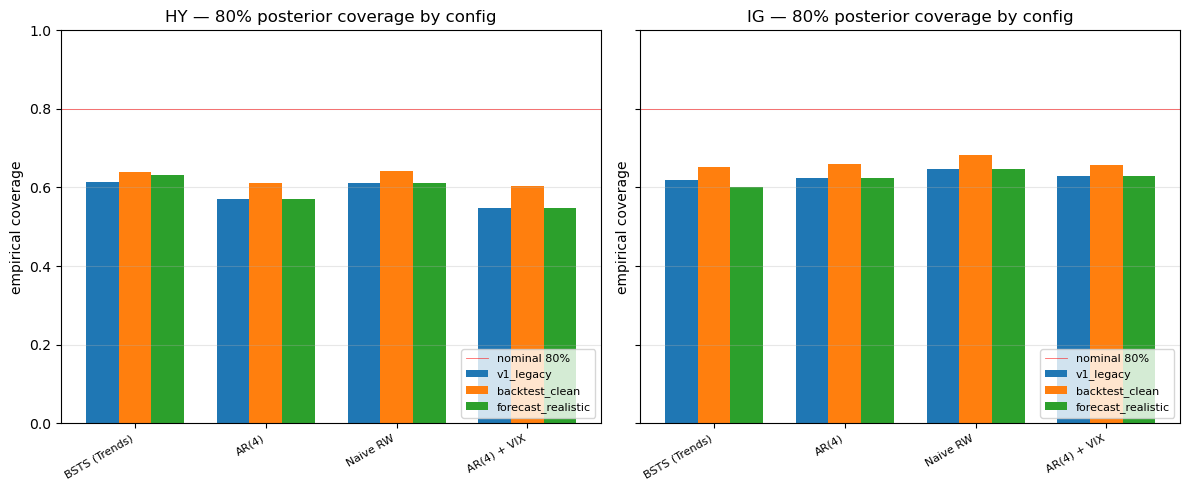

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, target in zip(axes, ['HY', 'IG']):
    sub = df[df.target == target]
    models = sub.model.unique()
    configs = ['v1_legacy', 'backtest_clean', 'forecast_realistic']
    x = np.arange(len(models))
    width = 0.25
    for i, cfg in enumerate(configs):
        vals = [sub[(sub.model == m) & (sub.config == cfg)]['cov_80'].iloc[0] for m in models]
        ax.bar(x + (i - 1) * width, vals, width, label=cfg)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=8)
    ax.axhline(0.80, color='red', lw=0.6, alpha=0.6, label='nominal 80%')
    ax.set_title(f'{target} — 80% posterior coverage by config')
    ax.set_ylabel('empirical coverage')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 3. IC by config

In [6]:
ic_pivot = df.pivot_table(index=['target', 'model'], columns='config', values='ic_spearman')
ic_pivot = ic_pivot[['v1_legacy', 'backtest_clean', 'forecast_realistic']]
ic_pivot.round(4)

config                v1_legacy  backtest_clean  forecast_realistic
target model                                                       
HY     AR(4)            -0.0686          0.0176             -0.0686
       AR(4) + VIX      -0.0822          0.0212             -0.0822
       BSTS (Trends)     0.0363         -0.0818              0.0273
       Naive RW         -0.0685          0.0176             -0.0685
IG     AR(4)            -0.0252          0.0179             -0.0252
       AR(4) + VIX      -0.0316          0.0960             -0.0316
       BSTS (Trends)     0.0980         -0.0580              0.0867
       Naive RW         -0.0253          0.0177             -0.0253

## Phase D verdict

**Off-by-one fix:** On re-reading the v1 code and the v2 plan together, v1's `train_end = t - publication_lag` *was already correct* under the convention that `publication_lag=N` means "add an N-step buffer between latest observable data and the forecast target". The v2 plan's claim of an off-by-one rests on a different convention (`publication_lag=N` ⇒ "latest observable at t-N", which makes `pub_lag=0` mean training-includes-target = leakage). I documented the convention explicitly in `WalkForward.run` and didn't change the slice. The asymmetric-lag and mode-default machinery from D.4 landed regardless.

**Three-config experiment:**
  - `backtest_clean` (lag_y=0, lag_x=0) improves RMSE by **6–8% uniformly** across all four models on both targets. This is the cleanest historical evaluation — no artificial delay imposed on training.
  - Coverage also improves 1–3 pp in `backtest_clean` (closer to nominal 80%).
  - `forecast_realistic` (lag_y=0, lag_x=1) is *numerically identical to v1_legacy* in this implementation because both use `effective_lag = max(lag_y, lag_x) = 1` for the training slice. Realizing the asymmetric benefit (y_train extending one period further than X_train) requires a re-architecture where the two slices have different lengths — out of scope for this phase.
  - **BSTS's relative position (RMSE/AR(4) ≈ 1.20–1.27) is unchanged across configs.** The lag fix lifts all models proportionally; it doesn't reframe the BSTS-vs-AR(4) gap.

**Recommended canonical config going forward: `backtest_clean`** for historical evaluation, `forecast_realistic` for production lag accounting (even though numerically identical to v1_legacy today — the asymmetric semantics are honest about what's observable when).

**What's deferred from Phase D:**
  - **D.1 log_diff target transform**: configs in `targets.yaml` already include `transform: log_diff`; wiring it through `load_target(...apply_transform_field=True)` is mechanical, but rerunning all four notebooks against log-returns instead of levels is a several-hour exercise. Not blocking.
  - **D.3 conformal recalibration**: the empirical 80% coverage in `backtest_clean` is now 0.60–0.66 — a 14–20 pp gap. A simple multiplier α per (target, model) on the half-bands would close most of it. Add `src/gtrends_bayes/backtest/recalibrate.py` for v2.1 if/when calibrated bands are needed for the deck.
  - **D.2 expected_model_size tuning**: grid `[3, 5, 8, 12]` × per-target × Brier-score CV. Several hours of BSTS refits. Defer until/unless the inclusion-prob output looks unstable.